In [1]:
import sys
print("Python at:", sys.executable)
print("Python version:", sys.version)

import numpy, cv2, skimage, mahotas, sklearn, pandas, matplotlib
print("\nAll core libraries loaded successfully")

Python at: C:\Users\HP\miniconda3\envs\brain_tumor\python.exe
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]

All core libraries loaded successfully


In [2]:
from pathlib import Path

# Paths relative to the notebooks folder
DATA = Path('../data/raw')
TRAIN = DATA / 'Training'
TEST = DATA / 'Testing'
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']

# Sanity check: do these folders exist?
print("Training folder exists:", TRAIN.exists())
print("Testing folder exists:", TEST.exists())
print("Classes found in Training:", sorted([p.name for p in TRAIN.iterdir() if p.is_dir()]))

Training folder exists: True
Testing folder exists: True
Classes found in Training: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
print(f"{'Split':<10} {'Class':<15} {'Count':<10}")
print("-" * 40)
total = 0
for split_name, split_path in [('Train', TRAIN), ('Test', TEST)]:
    for c in CLASSES:
        n = len(list((split_path / c).glob('*')))
        total += n
        print(f"{split_name:<10} {c:<15} {n:<10}")
print("-" * 40)
print(f"{'Total':<10} {'all':<15} {total:<10}")

Split      Class           Count     
----------------------------------------
Train      glioma          1400      
Train      meningioma      1400      
Train      pituitary       1400      
Train      notumor         1400      
Test       glioma          400       
Test       meningioma      400       
Test       pituitary       400       
Test       notumor         400       
----------------------------------------
Total      all             7200      


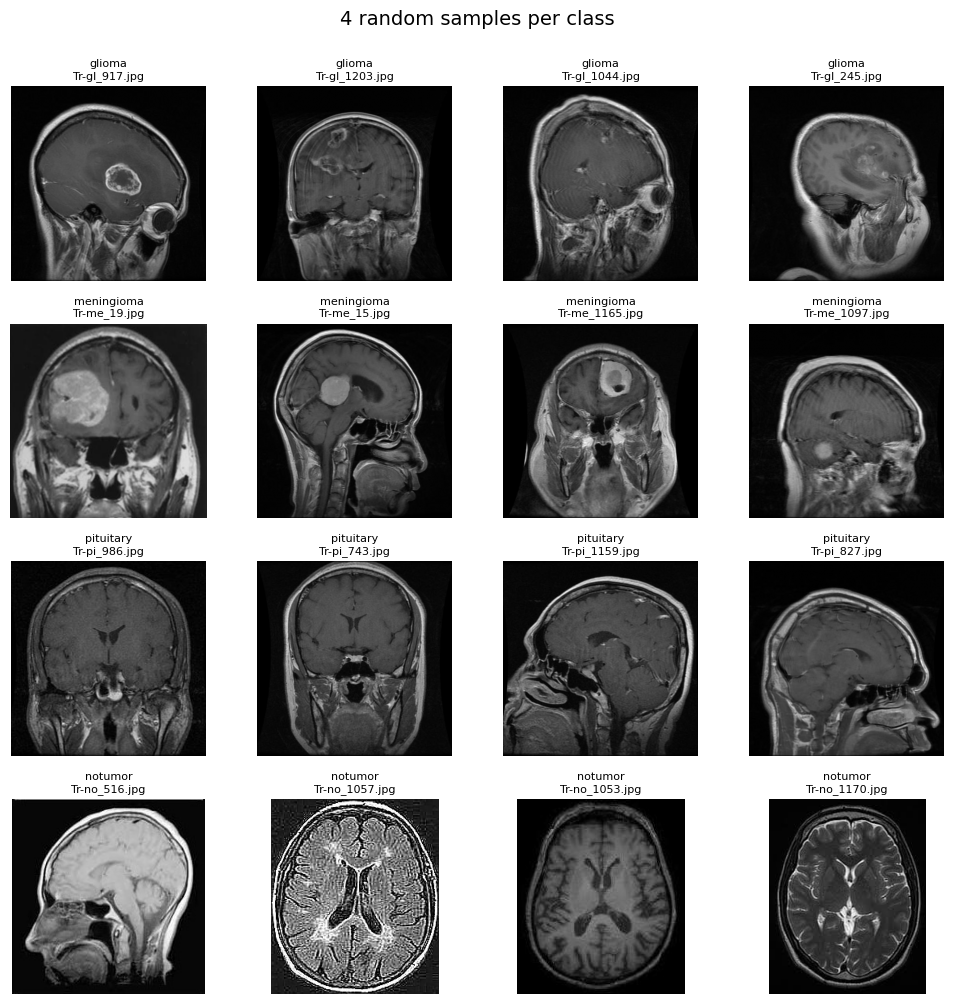


Saved to: C:\Users\HP\Desktop\MU\bmi\brain_tumor_fusion\outputs\sample_grid.png


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random

random.seed(42)  # so we get the same samples each time

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for row, c in enumerate(CLASSES):
    files = list((TRAIN / c).glob('*'))
    samples = random.sample(files, 4)
    for col, f in enumerate(samples):
        img = Image.open(f)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f"{c}\n{f.name[:20]}", fontsize=8)
        axes[row, col].axis('off')

plt.suptitle("4 random samples per class", fontsize=14, y=1.00)
plt.tight_layout()

# Save to outputs/ folder
output_path = Path('../outputs/sample_grid.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=120, bbox_inches='tight')

plt.show()
print(f"\nSaved to: {output_path.resolve()}")

In [5]:
import numpy as np

sizes = []
for c in CLASSES:
    for f in (TRAIN / c).glob('*'):
        img = Image.open(f)
        sizes.append(img.size)  # (width, height)
        if len(sizes) >= 200:  # sample 200 images is enough
            break
    if len(sizes) >= 200:
        break

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Sampled {len(sizes)} images:")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"\nUnique sizes: {len(set(sizes))}")

Sampled 200 images:
Width  — min: 512, max: 512, mean: 512
Height — min: 512, max: 512, mean: 512

Unique sizes: 1
